<a href="https://colab.research.google.com/github/tonHS/Canadian-Crime-Trends/blob/Sandbox/retail_crime_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Organized Retail Crime Analysis
## Shoplifting Trends Visualization

This notebook fetches Statistics Canada data and creates line graphs for:
- Shoplifting over $5,000
- Shoplifting under $5,000

In [16]:
import pandas as pd
import numpy as np
import requests
import zipfile
from io import BytesIO
import matplotlib.pyplot as plt
from datetime import datetime

print("="*80)
print("ORGANIZED RETAIL CRIME VISUALS")
print("="*80)
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Data Source: Statistics Canada Table 35-10-0062-01")
print("="*80)

ORGANIZED RETAIL CRIME VISUALS
Generated: 2025-11-26 02:51:31
Data Source: Statistics Canada Table 35-10-0062-01


In [17]:
# Fetch data from StatCan
print("\nFetching data from Statistics Canada...")

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
api_url = "https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/35100062/en"

response = requests.get(api_url, headers=headers, timeout=60)
zip_url = response.json()['object']

zip_response = requests.get(zip_url, headers=headers, timeout=60)

with zipfile.ZipFile(BytesIO(zip_response.content)) as z:
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]
    df_raw = pd.read_csv(z.open(csv_files[0]), low_memory=False)

print(f"✓ Loaded: {len(df_raw):,} rows")


Fetching data from Statistics Canada...
✓ Loaded: 702 rows


In [18]:
# Prepare data
df = df_raw.copy()
df['Year'] = df['REF_DATE'].astype(int)
df = df[df['VALUE'].notna()]

print(f"✓ Years: {df['Year'].min()} to {df['Year'].max()}")
print(f"✓ Violations: {df['Most serious violation'].nunique():,}")

# CRITICAL: Set target geography
TARGET_GEO = 'Canada, selected police services'
print(f"✓ Target geography: {TARGET_GEO}")

✓ Years: 2016 to 2024
✓ Violations: 78
✓ Target geography: Canada, selected police services


In [19]:
# Filter for shoplifting violations and target geography
print("\nFiltering shoplifting data...")

# The 'Statistics' column is missing from the dataset. Assuming 'VALUE' represents the desired metric directly.
df_filtered_data = df.copy()

# Filter for target geography
df_filtered = df_filtered_data[df_filtered_data['GEO'] == TARGET_GEO].copy()

# Filter for shoplifting violations
shoplifting_over = df_filtered[
    df_filtered['Most serious violation'].str.contains('Shoplifting over', case=False, na=False)
].copy()

shoplifting_under = df_filtered[
    df_filtered['Most serious violation'].str.contains('Shoplifting \$5,000 or under', case=False, na=False)
].copy()

print(f"✓ Shoplifting over $5,000: {len(shoplifting_over)} records")
print(f"✓ Shoplifting under $5,000: {len(shoplifting_under)} records")

# Check if we have data
if len(shoplifting_over) == 0 or len(shoplifting_under) == 0:
    print("\n⚠ WARNING: No data found. Checking available violations...")
    print("\nAvailable violations containing 'shoplifting':")
    shoplifting_violations = df_filtered[
        df_filtered['Most serious violation'].str.contains('shoplifting', case=False, na=False)
    ]['Most serious violation'].unique()
    for v in shoplifting_violations:
        print(f"  - {v}")


Filtering shoplifting data...
✓ Shoplifting over $5,000: 9 records
✓ Shoplifting under $5,000: 9 records


<>:16: SyntaxWarning: invalid escape sequence '\$'
<>:16: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3961865195.py:16: SyntaxWarning: invalid escape sequence '\$'
  df_filtered['Most serious violation'].str.contains('Shoplifting \$5,000 or under', case=False, na=False)


In [20]:
# Aggregate data by year
print("\nAggregating data by year...")

# Group by year and sum values
over_5k = shoplifting_over.groupby('Year')['VALUE'].sum().reset_index()
over_5k.columns = ['Year', 'Incidents']

under_5k = shoplifting_under.groupby('Year')['VALUE'].sum().reset_index()
under_5k.columns = ['Year', 'Incidents']

print(f"✓ Over $5,000: {len(over_5k)} years of data")
print(f"✓ Under $5,000: {len(under_5k)} years of data")

# Display sample data
print("\nSample data (Over $5,000):")
print(over_5k.head())
print("\nSample data (Under $5,000):")
print(under_5k.head())


Aggregating data by year...
✓ Over $5,000: 9 years of data
✓ Under $5,000: 9 years of data

Sample data (Over $5,000):
   Year  Incidents
0  2016          8
1  2017          7
2  2018         13
3  2019          7
4  2020          7

Sample data (Under $5,000):
   Year  Incidents
0  2016         62
1  2017        202
2  2018        127
3  2019        115
4  2020        125



Generating visualizations...
✓ Saved: shoplifting_over_5000_trends.png


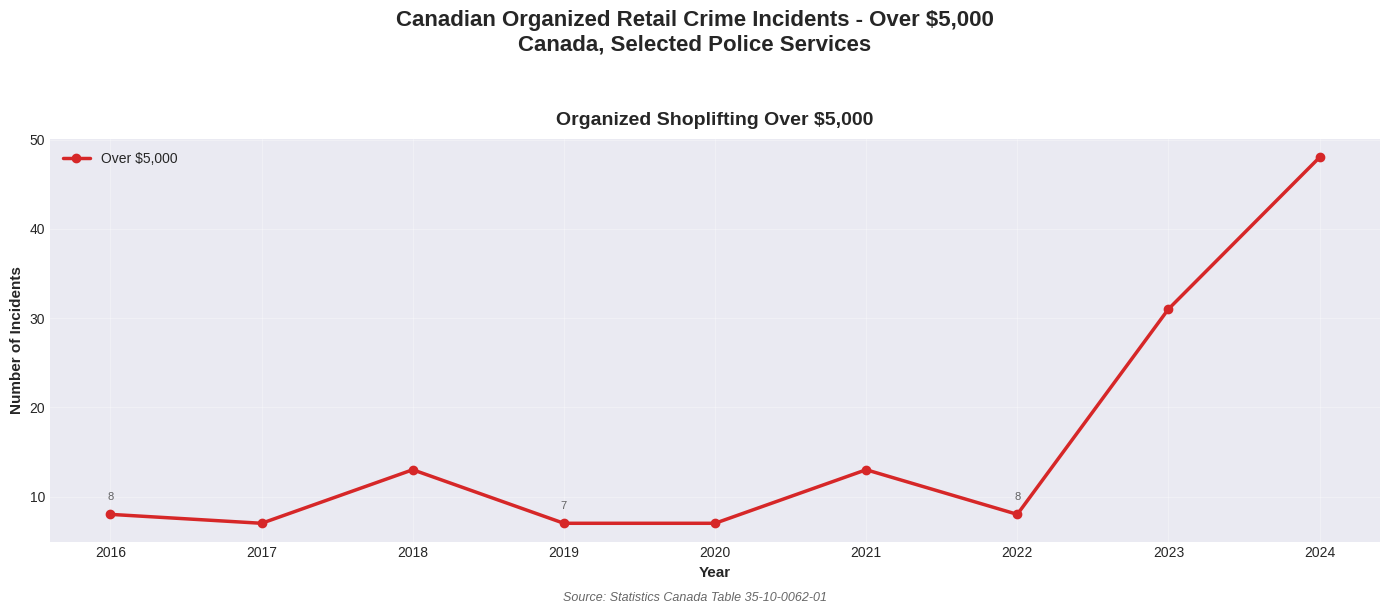

✓ Saved: shoplifting_under_5000_trends.png


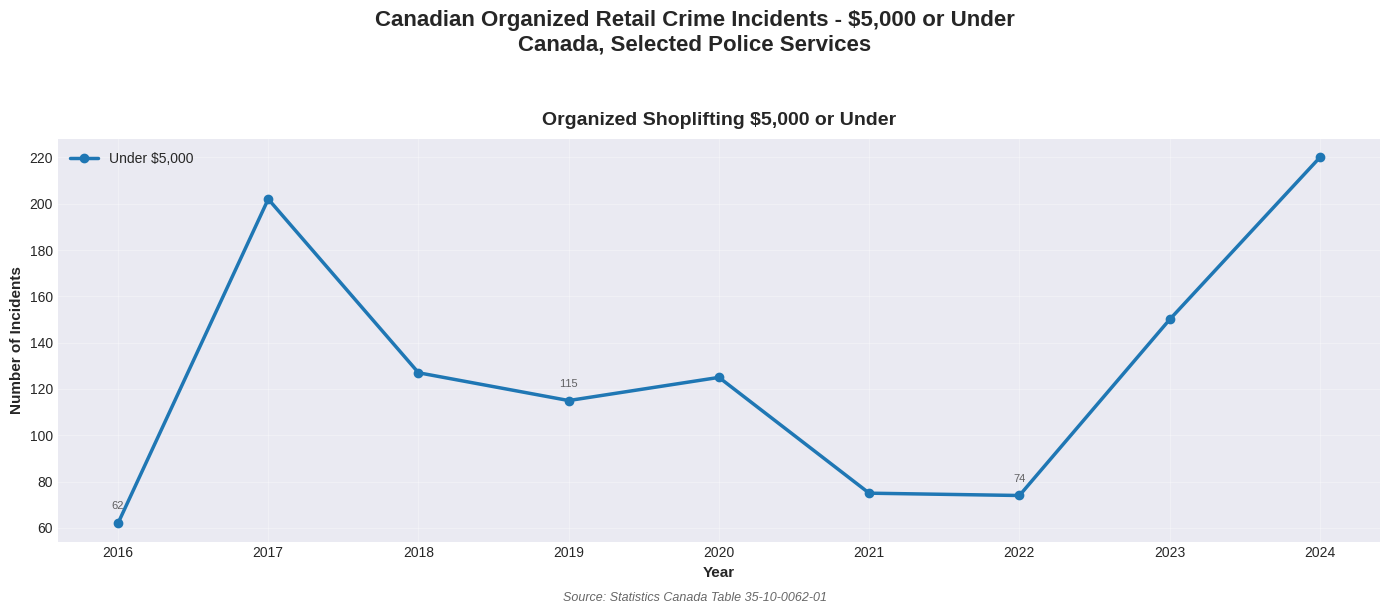

In [21]:
# Create visualizations
print("\nGenerating visualizations...")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Graph 1: Shoplifting Over $5,000
fig1, ax1 = plt.subplots(figsize=(14, 6))
fig1.suptitle('Canadian Organized Retail Crime Incidents - Over $5,000\nCanada, Selected Police Services',
              fontsize=16, fontweight='bold', y=0.995)

ax1.plot(over_5k['Year'], over_5k['Incidents'],
         marker='o', linewidth=2.5, markersize=6, color='#d62728', label='Over $5,000')
ax1.set_title('Organized Shoplifting Over $5,000', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=10)

# Format y-axis with thousands separator
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add value labels on points
for idx, row in over_5k.iterrows():
    if idx % 3 == 0:  # Label every 3rd point to avoid crowding
        ax1.annotate(f"{int(row['Incidents']):,}",
                    xy=(row['Year'], row['Incidents']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8, alpha=0.7)

# Add source note for fig1
fig1.text(0.5, 0.01, 'Source: Statistics Canada Table 35-10-0062-01',
          ha='center', fontsize=9, style='italic', alpha=0.7)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig('shoplifting_over_5000_trends.png', dpi=300, bbox_inches='tight')
print("✓ Saved: shoplifting_over_5000_trends.png")
plt.show()

# Graph 2: Shoplifting Under $5,000
fig2, ax2 = plt.subplots(figsize=(14, 6))
fig2.suptitle('Canadian Organized Retail Crime Incidents - $5,000 or Under\nCanada, Selected Police Services',
              fontsize=16, fontweight='bold', y=0.995)

ax2.plot(under_5k['Year'], under_5k['Incidents'],
         marker='o', linewidth=2.5, markersize=6, color='#1f77b4', label='Under $5,000')
ax2.set_title('Organized Shoplifting $5,000 or Under', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=10)

# Format y-axis with thousands separator
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add value labels on points
for idx, row in under_5k.iterrows():
    if idx % 3 == 0:  # Label every 3rd point to avoid crowding
        ax2.annotate(f"{int(row['Incidents']):,}",
                    xy=(row['Year'], row['Incidents']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8, alpha=0.7)

# Add source note for fig2
fig2.text(0.5, 0.01, 'Source: Statistics Canada Table 35-10-0062-01',
          ha='center', fontsize=9, style='italic', alpha=0.7)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig('shoplifting_under_5000_trends.png', dpi=300, bbox_inches='tight')
print("✓ Saved: shoplifting_under_5000_trends.png")
plt.show()

In [22]:
# Calculate and display summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\nShoplifting Over $5,000:")
print(f"  Total incidents (all years): {over_5k['Incidents'].sum():,.0f}")
print(f"  Average per year: {over_5k['Incidents'].mean():,.0f}")
print(f"  Highest year: {over_5k.loc[over_5k['Incidents'].idxmax(), 'Year']:.0f} ({over_5k['Incidents'].max():,.0f} incidents)")
print(f"  Lowest year: {over_5k.loc[over_5k['Incidents'].idxmin(), 'Year']:.0f} ({over_5k['Incidents'].min():,.0f} incidents)")

if len(over_5k) > 1:
    first_year = over_5k.iloc[0]['Incidents']
    last_year = over_5k.iloc[-1]['Incidents']
    pct_change = ((last_year - first_year) / first_year) * 100
    print(f"  Change from {over_5k.iloc[0]['Year']:.0f} to {over_5k.iloc[-1]['Year']:.0f}: {pct_change:+.1f}%")

print("\nShoplifting Under $5,000:")
print(f"  Total incidents (all years): {under_5k['Incidents'].sum():,.0f}")
print(f"  Average per year: {under_5k['Incidents'].mean():,.0f}")
print(f"  Highest year: {under_5k.loc[under_5k['Incidents'].idxmax(), 'Year']:.0f} ({under_5k['Incidents'].max():,.0f} incidents)")
print(f"  Lowest year: {under_5k.loc[under_5k['Incidents'].idxmin(), 'Year']:.0f} ({under_5k['Incidents'].min():,.0f} incidents)")

if len(under_5k) > 1:
    first_year = under_5k.iloc[0]['Incidents']
    last_year = under_5k.iloc[-1]['Incidents']
    pct_change = ((last_year - first_year) / first_year) * 100
    print(f"  Change from {under_5k.iloc[0]['Year']:.0f} to {under_5k.iloc[-1]['Year']:.0f}: {pct_change:+.1f}%")

print("\n" + "="*80)
print("Analysis complete!")
print("="*80)


SUMMARY STATISTICS

Shoplifting Over $5,000:
  Total incidents (all years): 142
  Average per year: 16
  Highest year: 2024 (48 incidents)
  Lowest year: 2017 (7 incidents)
  Change from 2016 to 2024: +500.0%

Shoplifting Under $5,000:
  Total incidents (all years): 1,150
  Average per year: 128
  Highest year: 2024 (220 incidents)
  Lowest year: 2016 (62 incidents)
  Change from 2016 to 2024: +254.8%

Analysis complete!


In [23]:
# Optional: Export data to CSV
print("\nExporting data to CSV files...")

over_5k.to_csv('shoplifting_over_5000.csv', index=False)
print("✓ Saved: shoplifting_over_5000.csv")

under_5k.to_csv('shoplifting_under_5000.csv', index=False)
print("✓ Saved: shoplifting_under_5000.csv")

print("\nAll files ready for download!")


Exporting data to CSV files...
✓ Saved: shoplifting_over_5000.csv
✓ Saved: shoplifting_under_5000.csv

All files ready for download!
